この章で利用したサンプルデータstudent_data_mathのデータを使って、以下の問いに答えてください。ここで扱
うローレンツ曲線やジニ係数は、貧富の格差（地域別、国別など）を見るための指標として使われています（なお、
本問題は少し難易度が高いため、参考程度に見てください。詳細は、以前に紹介した統計学入門などの文献を参
照するか、ネットで検索してください）。
1. 一期目の数学データについて、男女別に昇順に並び替えをしてください。そして、横軸に人数の累積比率、縦
軸に一期目の値の累積比率をとってください。この曲線をローレンツ曲線といいます。このローレンツ曲線を男女
別に一期目の数学成績でグラフ化してください。
2. 不平等の程度を数値で表したものをジニ係数といいます。この値は、ローレンツ曲線と45度線で囲まれた部分の
面積の2倍で定義されて、0から1の値を取ります。値が大きければ大きいほど、不平等の度合いが大きくなりま
す。なお以下のようにジニ係数は定義できます。 は平均値です。

これを利用して、男女の一期目の成績について、ジニ係数をそれぞれ求めてください。

In [54]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

In [55]:
student_data_math = pd.read_csv('student-mat.csv', sep=';')

In [56]:
student_data_math_F = student_data_math[student_data_math['sex'] == 'F']
student_data_math_M = student_data_math[student_data_math['sex'] == 'M']

In [57]:
student_data_math_M.sort_values(by='G1', inplace=True)
student_data_math_F.sort_values(by='G1', inplace=True)

In [58]:
len_F = len(student_data_math_F)
len_M = len(student_data_math_M)

In [59]:
x_F = np.arange(len_F)
x_M = np.arange(len_M)
x_F_per = x_F / len_F
x_M_per = x_M / len_M

In [60]:
G1_M = np.array(list(itertools.accumulate(np.array(student_data_math_M['G1']).tolist())))
G1_F = np.array(list(itertools.accumulate(np.array(student_data_math_F['G1']).tolist())))

In [61]:
G1_M_per = G1_M / max(G1_M)
G1_F_per = G1_F / max(G1_F)

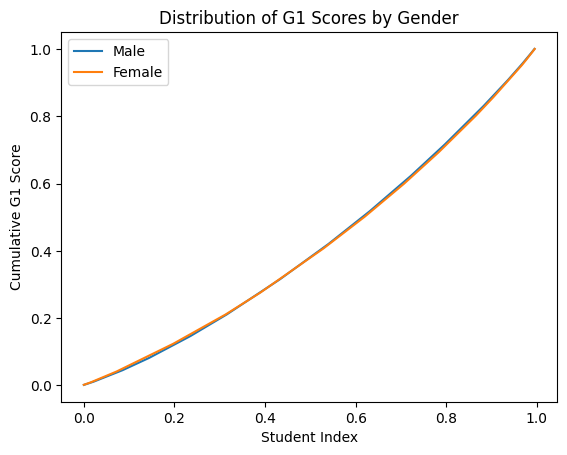

In [62]:
plt.plot(x_M_per, G1_M_per, label='Male')
plt.plot(x_F_per, G1_F_per, label='Female')
plt.xlabel('Student Index')
plt.ylabel('Cumulative G1 Score')
plt.title('Distribution of G1 Scores by Gender')
plt.legend()
plt.show()

In [75]:
# ジニ係数を求める
jini = 0.5
for i in range(len_F):
    if i == 0:
        jini -= (0 + G1_F_per[i])*G1_F_per[0]/2
    # elif i == len_F:
    #     jini -= (G1_F_per[i-1] + 1)*G1_F_per[0]/2
    else:
        jini -= (G1_F_per[i-1] + G1_F_per[i])*G1_F_per[0]/2

jini *= 2

In [76]:
jini

np.float64(0.688283721825259)

In [77]:
# ジニ係数を求める
jini = 0.5
for i in range(len_M):
    if i == 0:
        jini -= (0 + G1_M_per[i])*G1_M_per[0]/2
    # elif i == len_M:
    #     jini -= (G1_M_per[i-1] + 1)*G1_M_per[0]/2
    else:
        jini -= (G1_M_per[i-1] + G1_M_per[i])*G1_M_per[0]/2

jini *= 2

In [78]:
jini

np.float64(0.778798639455782)